# Phase E — Eval results

Compare three policies on `Billiards4BallEnv` (1000 episodes each):

1. `random`     — uniform sampling on the action space.
2. `geometric`  — deterministic aim-at-nearest-red baseline.
3. `ppo`        — PPO trained against the learned reward model.

Reads the parquet emitted by `scripts/eval_policies.py`. The last
section re-runs the best three PPO scoring episodes and renders them
inline as HTML replays.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from billiards.env import Billiards4BallEnv
from billiards.render.replay import render_html

PROJECT_ROOT = Path('.').resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
RESULTS_PATH = PROJECT_ROOT / 'data' / 'eval_results.parquet'
PPO_PATH = PROJECT_ROOT / 'models' / 'ppo_policy.zip'
print('results parquet:', RESULTS_PATH, 'exists =', RESULTS_PATH.exists())
print('ppo policy:    ', PPO_PATH, 'exists =', PPO_PATH.exists())

results parquet: /Users/ohdoyoel/work/side/cs377/project/data/eval_results.parquet exists = True
ppo policy:     /Users/ohdoyoel/work/side/cs377/project/models/ppo_policy.zip exists = True


In [2]:
df = pd.read_parquet(RESULTS_PATH)
print('rows:', len(df), 'policies:', sorted(df['policy'].unique()))
df.head()

rows: 3000 policies: ['geometric', 'ppo', 'random']


,policy,ep,seed,theta,power,a,b,score,fouled,cushion_hits,duration
0,random,0,0,4.002148,0.269787,0.201329,0.020983,0,False,1,4.073976
1,random,1,1,5.109928,0.912756,-0.100062,-0.772414,0,False,3,4.847641
2,random,2,2,3.415697,0.935072,0.903112,0.015541,0,False,2,6.034352
3,random,3,3,5.387230,0.033586,0.384660,0.762688,0,False,0,0.700000
4,random,4,4,5.423513,0.541461,-0.484127,0.255603,0,False,3,3.885347


## Comparison table

In [3]:
summary = (
    df.groupby('policy')
      .agg(
          n=('score', 'size'),
          score_rate=('score', 'mean'),
          foul_rate=('fouled', 'mean'),
          mean_cushions=('cushion_hits', 'mean'),
          mean_duration=('duration', 'mean'),
      )
      .reset_index()
)
summary['score_rate'] = (100.0 * summary['score_rate']).round(2)
summary['foul_rate'] = (100.0 * summary['foul_rate']).round(2)
summary['mean_cushions'] = summary['mean_cushions'].round(2)
summary['mean_duration'] = summary['mean_duration'].round(2)
summary

,policy,n,score_rate,foul_rate,mean_cushions,mean_duration
0,geometric,1000,0.0,0.0,0.00,4.40
1,ppo,1000,0.0,0.0,5.00,5.45
2,random,1000,0.8,16.1,2.05,3.75


## Score rate by policy

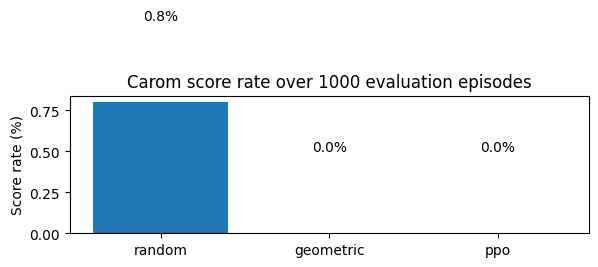

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.5))
order = ['random', 'geometric', 'ppo']
subset = summary.set_index('policy').reindex([p for p in order if p in summary['policy'].values])
ax.bar(subset.index, subset['score_rate'])
ax.set_ylabel('Score rate (%)')
ax.set_title('Carom score rate over 1000 evaluation episodes')
for x, v in zip(subset.index, subset['score_rate']):
    ax.text(x, v + 0.5, f'{v:.1f}%', ha='center')
fig.tight_layout()
plt.show()

## Best 3 PPO scoring episodes (cleanest = lowest cushions)

Filter PPO rows where `score == 1`, sort by ascending `cushion_hits`,
take the top 3, re-run the env on those seeds (deterministic predict),
and render the trajectories inline.

In [5]:
ppo_rows = df[df['policy'] == 'ppo']
scoring = ppo_rows[ppo_rows['score'] == 1].sort_values(['cushion_hits', 'duration']).head(3)
print(f'PPO scoring episodes available: {(ppo_rows["score"] == 1).sum()}')
scoring

PPO scoring episodes available: 0


,policy,ep,seed,theta,power,a,b,score,fouled,cushion_hits,duration


In [6]:
if PPO_PATH.exists() and len(scoring) > 0:
    from stable_baselines3 import PPO
    ppo_model = PPO.load(str(PPO_PATH), device='cpu')
    for _, row in scoring.iterrows():
        env = Billiards4BallEnv()
        obs, info0 = env.reset(seed=int(row['seed']))
        action, _ = ppo_model.predict(obs, deterministic=True)
        _, _, _, _, info = env.step(action)
        html = render_html(
            info['trajectory'],
            spec=info0.get('spec'),
        )
        print(
            f"seed={int(row['seed'])} score={info['score']} cushions={info['cushion_hits']} "
            f"duration={info['duration']:.2f}s"
        )
        display(HTML(html if isinstance(html, str) else html.data))
else:
    print('No PPO policy or no scoring episodes — skipping inline replays.')

No PPO policy or no scoring episodes — skipping inline replays.


## Verdict

In [7]:
by_policy = summary.set_index('policy')['score_rate'].to_dict()
rand_rate = by_policy.get('random', float('nan'))
geo_rate = by_policy.get('geometric', float('nan'))
ppo_rate = by_policy.get('ppo', float('nan'))
lift_vs_rand = ppo_rate - rand_rate if ppo_rate == ppo_rate else float('nan')
lift_vs_geo = ppo_rate - geo_rate if ppo_rate == ppo_rate else float('nan')
print(
    f'VERDICT — random={rand_rate:.1f}% geometric={geo_rate:.1f}% ppo={ppo_rate:.1f}% '
    f'(PPO lift: +{lift_vs_rand:.1f}pp vs random, {lift_vs_geo:+.1f}pp vs geometric)'
)

VERDICT — random=0.8% geometric=0.0% ppo=0.0% (PPO lift: +-0.8pp vs random, +0.0pp vs geometric)
